In [1]:
metaproject_name = 'Hypnomed_META'
subproject_name = 'hypnomed_pheno'

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJDIR = os.path.expanduser(f"~/projects/{metaproject_name}")
DATADIR = os.path.join(PROJDIR,f'DATA/{subproject_name}')
CODEDIR = os.path.join(PROJDIR,f'{subproject_name}')

In [3]:
file_name = os.path.join(DATADIR,'Pheno_Likert_scales_fMRI_Romy.csv')
print(file_name)
Likert_df = pd.read_csv(file_name, header = 0)
Likert_df

/Users/rb666/projects/Hypnomed_META/DATA/hypnomed_pheno/Pheno_Likert_scales_fMRI_Romy.csv


,Sujet,Sub_id_fMRI,Neucose_ID,Bloc,state,Version,age,genre,allcov_excluded,Stateq_Answ1,...,Stateq_Answ18,Stateq_Answ19,Stateq_Answ20,Stateq_Answ21,Stateq_Answ22,Stateq_Answ23,Baselineq_Answ1,Baselineq_Answ2,Baselineq_Answ3,Baselineq_Answ4
0,1,sub-25,KA001,1,C,B,034Y,F,0,7,...,3.0,7.0,1.0,2.0,1.0,5.0,7,1,2,1
1,5,sub-40,AV005,1,C,A,022Y,F,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,7,1,3,1
2,7,sub-34,AV007,1,C,A,026Y,M,0,3,...,8.0,9.0,9.0,9.0,3.0,7.0,8,6,5,5
3,14,sub-33,JC014,1,C,B,022Y,F,0,7,...,3.0,6.0,7.0,8.0,2.0,4.0,7,3,7,2
4,21,sub-08,GM021,1,C,B,063Y,M,0,9,...,5.0,5.0,5.0,7.0,2.0,5.0,9,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,94,sub-18,LD094,2,H,B,045Y,F,0,8,...,4.0,8.0,4.0,6.0,8.0,8.0,8,2,2,2
116,96,sub-39,BR096,3,H,A,032Y,M,1,7,...,4.0,6.0,9.0,4.0,3.0,6.0,8,7,3,9
117,100,sub-11,GP100,3,H,A,061Y,M,1,6,...,7.0,6.0,6.0,6.0,6.0,8.0,8,2,3,2
118,101,sub-31,DM101,2,H,B,047Y,F,1,8,...,7.0,4.0,8.0,7.0,5.0,8.0,7,2,4,2


## Modify the dataset so that it matches the nomenclature of Bigdataset.txt + Compute the Likert values

### Difficulty

Likert_df['difficulty'] = Likert_df['Stateq_Answ1'].astype(int) + Likert_df['Stateq_Answ2'].astype(int) + Likert_df['Stateq_Answ3'].astype(int)

- 1. I was able to follow the proposed audio instructions.
- 2. It was difficult to do what I was asked to do during the audio instructions.
- 3. I was distracted during audio instructions.


### Emotion

Likert_df['emotion'] = Likert_df['Stateq_Answ4'].astype(int) + Likert_df['Stateq_Answ5'].astype(int) + Likert_df['Stateq_Answ12'].astype(int)

- 4. The audio instructions aroused emotions in me.
- 5. The audio instructions reminded me of memories.
- 12. I was emotionally involved in the sensations evoked by the food pictures.


### Absoprtion

Likert_df['absorp'] = Likert_df['Stateq_Answ11'].astype(int) + Likert_df['Stateq_Answ13'].astype(int) + Likert_df['Stateq_Answ14'].astype(int)

- 11. The intensity of sensations aroused by the food pictures was strong.
- 13. I was absorbed by the pictures of food.
- 14. I was absorbed by the sensations that the food pictures evoked in me.


### Meta-awareness

Likert_df['meta'] = Likert_df['Stateq_Answ16'].astype(int) + Likert_df['Stateq_Answ17'].astype(int)

- 16. During the presentation of the food pictures I observed my thoughts as passing mental events.
- 17. Looking at the images, I was aware that my thoughts were subjective interpretations and that they did not necessarily correspond to the qualities of the images themselves.


### Realness

Likert_df['realness'] = Likert_df['Stateq_Answ6'].astype(int) + Likert_df['Stateq_Answ7'].astype(int) + Likert_df['Stateq_Answ8'].astype(int) + Likert_df['Stateq_Answ9'].astype(int) + Likert_df['Stateq_Answ10'].astype(int) + Likert_df['Stateq_Answ15'].astype(int)

- 6. Watching the food pictures made me want to eat them.
- 7. Watching the food pictures made my mouth water.
- 8. The food seemed real to me.
- 9. My appetite increased as the images appeared.
- 10. The sensations I had when I saw the food pictures were similar to the sensations I have when I am in front of real food.


In [4]:
Likert_df.keys()

# Creating new columns
Likert_categories = ['difficulty','emotion','absorp','meta','realness'] #categories in which the 23 questions will be computed

Likert_df['difficulty'] = Likert_df['Stateq_Answ1'].astype(int) + Likert_df['Stateq_Answ2'].astype(int) + Likert_df['Stateq_Answ3'].astype(int)
Likert_df['emotion'] = Likert_df['Stateq_Answ4'].astype(int) + Likert_df['Stateq_Answ5'].astype(int) + Likert_df['Stateq_Answ12'].astype(int)
Likert_df['absorp'] = Likert_df['Stateq_Answ11'].astype(int) + Likert_df['Stateq_Answ13'].astype(int) + Likert_df['Stateq_Answ14'].astype(int)
Likert_df['meta'] = Likert_df['Stateq_Answ16'].astype(int) + Likert_df['Stateq_Answ17'].astype(int)
Likert_df['realness'] = Likert_df['Stateq_Answ6'].astype(int) + Likert_df['Stateq_Answ7'].astype(int) + Likert_df['Stateq_Answ8'].astype(int) + Likert_df['Stateq_Answ9'].astype(int) + Likert_df['Stateq_Answ10'].astype(int) + Likert_df['Stateq_Answ15'].astype(int)


Likert_mapping = {
    "X01_following_instructions": "Stateq_Answ1",
    "X02_difficulty": "Stateq_Answ2",
    "X03_distractedness": "Stateq_Answ3",
    "X04_emotivity": "Stateq_Answ4",
    "X05_memories": "Stateq_Answ5",
    "X012_emotional_implication_in_sensations": "Stateq_Answ12",
    "X011_intensity_of_sensation": "Stateq_Answ11",
    "X013_absorption_in_foods": "Stateq_Answ13",
    "X014_absorption_in_sensation": "Stateq_Answ14",
    "X016_observing_thoughts": "Stateq_Answ16",
    "X017_thoughts_as_interpretations_of_reality": "Stateq_Answ17",
    "X06_appetite": "Stateq_Answ6",
    "X07_mouthwatering": "Stateq_Answ7",
    "X08_realness_of_pictures": "Stateq_Answ8",
    "X09_appetite_increase": "Stateq_Answ9",
    "X010_realness_of_sensation": "Stateq_Answ10",
    "X015_realness_of_sensations": "Stateq_Answ15",
}

# Copy the dataframe
df = Likert_df.copy()

# Reverse the column mapping
reverse_mapping = {v: k for k, v in Likert_mapping.items()}

# Define a list of other columns that you want to keep
other_columns = ["Sujet", "Bloc", "state", "Version", "genre","age", "allcov_excluded"]

# Create a new dataframe with the columns renamed according to the reverse mapping
df_renamed = df.rename(columns=reverse_mapping)

# Create a list of columns in the desired order
ordered_columns = other_columns + [col for col in df_renamed.columns if col not in other_columns]

# Reorder the columns in the dataframe
new_df = df_renamed[ordered_columns]
Likert_questions = list(key for key in new_df.keys() if key.startswith('X'))
print(Likert_questions)

['X01_following_instructions', 'X02_difficulty', 'X03_distractedness', 'X04_emotivity', 'X05_memories', 'X06_appetite', 'X07_mouthwatering', 'X08_realness_of_pictures', 'X09_appetite_increase', 'X010_realness_of_sensation', 'X011_intensity_of_sensation', 'X012_emotional_implication_in_sensations', 'X013_absorption_in_foods', 'X014_absorption_in_sensation', 'X015_realness_of_sensations', 'X016_observing_thoughts', 'X017_thoughts_as_interpretations_of_reality']


## Delta compute
Compute the delta between states and Control condition. So :
- Value_delta = Value_Meditation - Value_Control

In [5]:
# Creating data.ctrl dataframe : Only data for Control condition
data_ctrl = new_df.loc[new_df['Bloc'] == 1].drop_duplicates()
# data_ctrl = data_ctrl[['Sujet', 'Version','state','Bloc', 'age', 'genre','difficulty', 'emotion', 'absorp', 'meta', 'realness']]
data_ctrl = data_ctrl[['Sujet','difficulty', 'emotion', 'absorp', 'meta', 'realness']]
data_ctrl = data_ctrl.rename(columns={
    'difficulty': 'Ctrl_difficulty',
    'emotion': 'Ctrl_emotion',
    'absorp': 'Ctrl_absorp',
    'meta': 'Ctrl_meta',
    'realness': 'Ctrl_realness'
})
data_ctrl.head()

,Sujet,Ctrl_difficulty,Ctrl_emotion,Ctrl_absorp,Ctrl_meta,Ctrl_realness
0,1,17,5,6,2,23
1,5,21,3,3,3,8
2,7,20,22,17,17,33
3,14,18,8,13,13,32
4,21,12,17,13,13,24


In [6]:
# Creating data.delta dataframe : Only data for non control condition
data_delta = new_df.loc[new_df['Bloc'] != 1]
data_delta = pd.merge(data_delta, data_ctrl, on='Sujet', how='left')
data_delta['difficulty_delta'] = data_delta['difficulty'] - data_delta['Ctrl_difficulty']
data_delta['emotion_delta'] = data_delta['emotion'] - data_delta['Ctrl_emotion']
data_delta['absorp_delta'] = data_delta['absorp'] - data_delta['Ctrl_absorp']
data_delta['meta_delta'] = data_delta['meta'] - data_delta['Ctrl_meta']
data_delta['realness_delta'] = data_delta['realness'] - data_delta['Ctrl_realness']
data_delta = data_delta[['Sujet', 'Bloc', 'age', 'genre', 'Version', 'state', 
                           'difficulty_delta', 'emotion_delta', 'absorp_delta', 'meta_delta', 'realness_delta']].drop_duplicates()



data_delta.to_csv('/Users/rb666/projects/Hypnomed_META/DATA/hypnomed_pheno/data_delta.csv', index=False)

# Removing donne.ctrl
del data_ctrl


In [11]:
data.head()

,Sujet,Bloc,age,genre,Version,state,difficulty_delta,emotion_delta,absorp_delta,meta_delta,realness_delta,combined_score
0,1,3,034Y,F,B,M,-3,2,0,10,-2,-10
1,5,2,022Y,F,A,M,-9,0,0,6,-2,-8
2,7,2,026Y,M,A,M,0,-2,2,0,-17,-17
3,14,3,022Y,F,B,M,0,3,-5,-1,-2,-3
4,21,3,063Y,M,B,M,4,1,2,-3,-7,-1


   Sujet  Bloc   age genre Version state  difficulty_delta  emotion_delta   
0      1     3  034Y     F       B     M                -3              2  \
1      5     2  022Y     F       A     M                -9              0   
2      7     2  026Y     M       A     M                 0             -2   
3     14     3  022Y     F       B     M                 0              3   
4     21     3  063Y     M       B     M                 4              1   

   absorp_delta  meta_delta  realness_delta  combined_score  
0             0          10              -2             -10  
1             0           6              -2              -8  
2             2           0             -17             -17  
3            -5          -1              -2              -3  
4             2          -3              -7              -1  


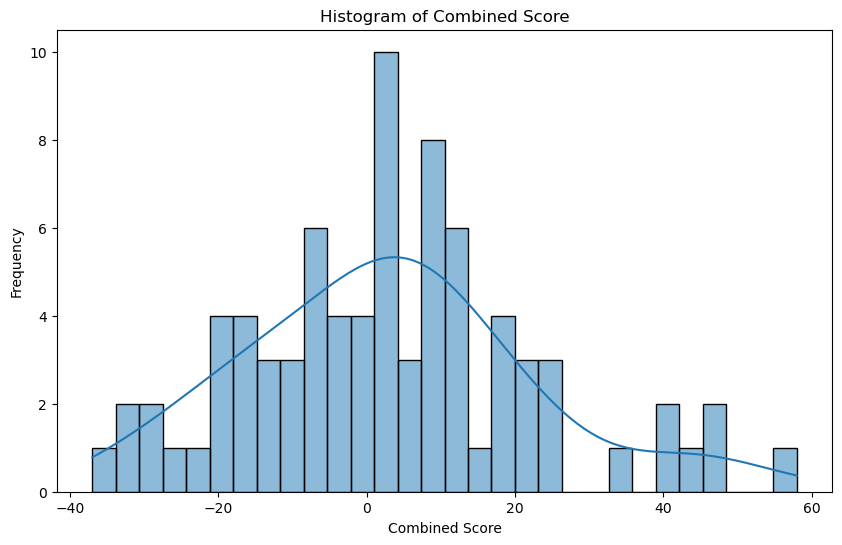

In [7]:
# Calculate the combined_score : This calculation is based on the coefficients provided: Realness, absorption, and emotion have a coefficient of +1, and meta-awareness has a coefficient of -1.
data = data_delta.copy()
data['combined_score'] = data['realness_delta'] + data['absorp_delta'] + data['emotion_delta'] - data['meta_delta']

# Display the first few rows of the data
print(data.head())

# Descriptive statistics of combined_score
data['combined_score'].describe()

# Histogram of combined_score
plt.figure(figsize=(10, 6))
sns.histplot(data['combined_score'], kde=True, bins=30)
plt.title('Histogram of Combined Score')
plt.xlabel('Combined Score')
plt.ylabel('Frequency')
plt.show()

In [10]:
print(data.head())
data['combined_score'].describe()

   Sujet  Bloc   age genre Version state  difficulty_delta  emotion_delta   
0      1     3  034Y     F       B     M                -3              2  \
1      5     2  022Y     F       A     M                -9              0   
2      7     2  026Y     M       A     M                 0             -2   
3     14     3  022Y     F       B     M                 0              3   
4     21     3  063Y     M       B     M                 4              1   

   absorp_delta  meta_delta  realness_delta  combined_score  
0             0          10              -2             -10  
1             0           6              -2              -8  
2             2           0             -17             -17  
3            -5          -1              -2              -3  
4             2          -3              -7              -1  


count    80.000000
mean      3.000000
std      19.518897
min     -37.000000
25%     -10.000000
50%       2.000000
75%      13.000000
max      58.000000
Name: combined_score, dtype: float64

# STATS

## Functions definition

- Boxplot : provides a visual representation of the distribution of the variable of interest across different blocks ('Bloc') and states ('state')
- Kernel Density Estimate plot : provides a smoothed representation of the distribution of the variable of interest across different states. The use of kernel smoothing to plot values allow for smoother distributions by smoothing out the noise. The peaks of a density plot help display where values are concentrated over the interval.
- Linear regression with the ordinary least squares (OLS) method : The dependent variable is the variable of interest, and the independent variables are the interaction between the 'state' and 'Bloc'.

In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.sandbox.stats.multicomp import MultiComparison
from statsmodels.stats.multitest import multipletests

def analysis_al_python(var_interest, datas):
    datas['col_interest'] = datas[var_interest]

    # boxplot 
    sns.boxplot(x='Bloc', y='col_interest', hue='state', data=datas) #datas correspond to our data_delta
    plt.title(var_interest)
    plt.show()

    # density plot : Plot univariate or bivariate distributions using kernel density estimation.
    sns.kdeplot(data=datas, x='col_interest', hue='state')
    plt.title(var_interest)
    plt.show()

    # OLS regression
    model = smf.ols('col_interest ~ state*Bloc', data=datas).fit()
    print(model.summary())

    # ANOVA results
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # plot model
    # Here we will plot the predictions from our model
    predictions = model.predict(datas[['state', 'Bloc']])
    sns.lineplot(data=datas, x='Bloc', y=predictions,hue=datas['state'])
    plt.title('Predicted Values')
    plt.show()

    # Post-hoc testing with multiple comparisons
    mc = MultiComparison(datas['col_interest'], datas['state'])
    result = mc.tukeyhsd()

    # Adjust the p-values from the Tukey HSD test using the FDR method
    reject, pvals_corrected, _, _ = multipletests(result.pvalues, method='fdr_bh')
    print(result)
    print('FDR corrected p-values: ', pvals_corrected)

    # Defining contrasts
    contrasts = {
        "Abso_3 VS Abso_2": np.array([-1, 0, 1, 0]),
        "Meta_3 VS Meta_2": np.array([0, -1, 0, 1]),
        "Abso_2 VS Meta_2": np.array([1, -1, 0, 0]),
        "Abso_3 VS Meta_3": np.array([0, 0, -1, 1])
    }

    # Store everything in a dictionary
    output = {
        'anova_table': anova_table,
        'predictions_plot': plt,
        'emerg_test': pvals_corrected,
        'post_hoc': contrasts # This would usually include the contrast results, not the contrasts themselves
    }

    return output


## Run analysis

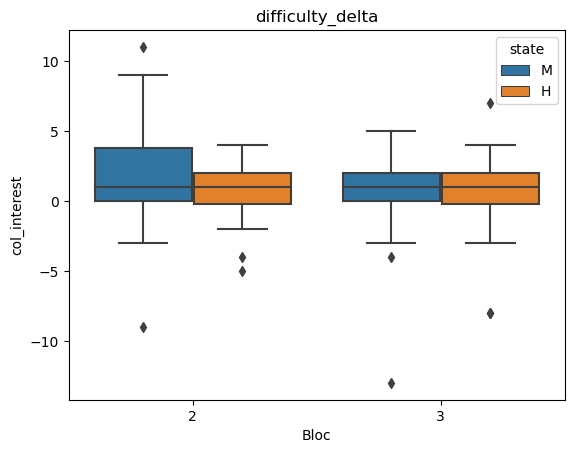

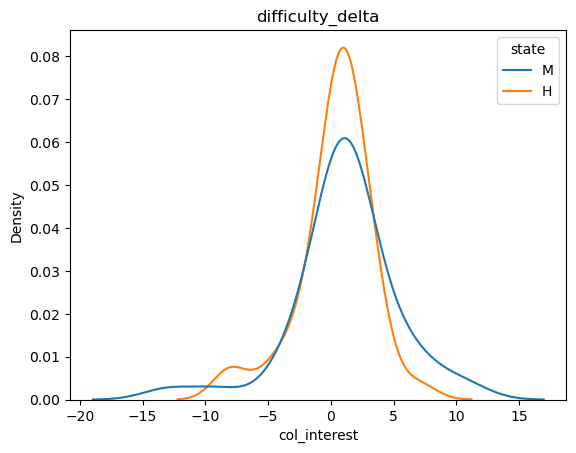

                            OLS Regression Results                            
Dep. Variable:           col_interest   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.049
Date:                Thu, 15 Jun 2023   Prob (F-statistic):              0.376
Time:                        10:16:21   Log-Likelihood:                -213.71
No. Observations:                  80   AIC:                             435.4
Df Residuals:                      76   BIC:                             445.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.8500      2.894     

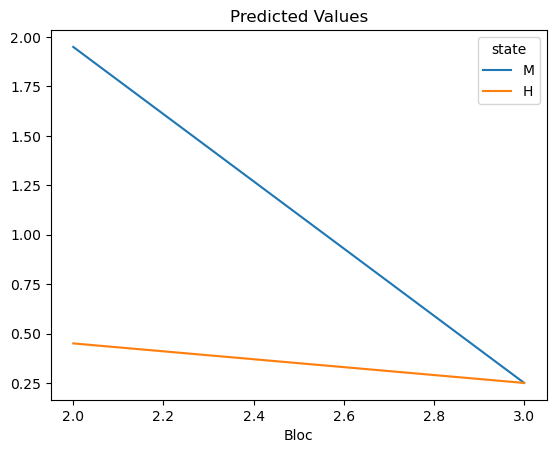

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     H      M     0.75 0.3539 -0.8509 2.3509  False
---------------------------------------------------
FDR corrected p-values:  [0.35385244]


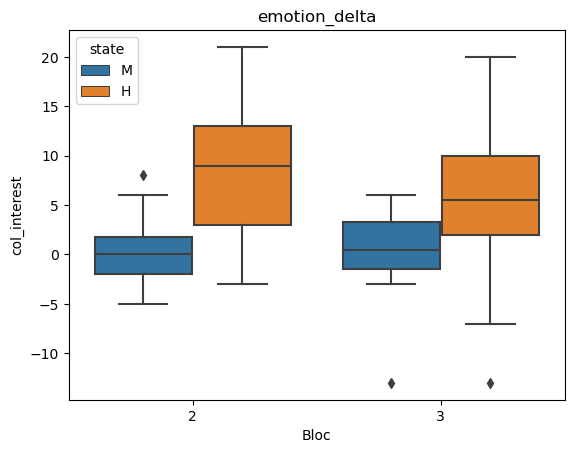

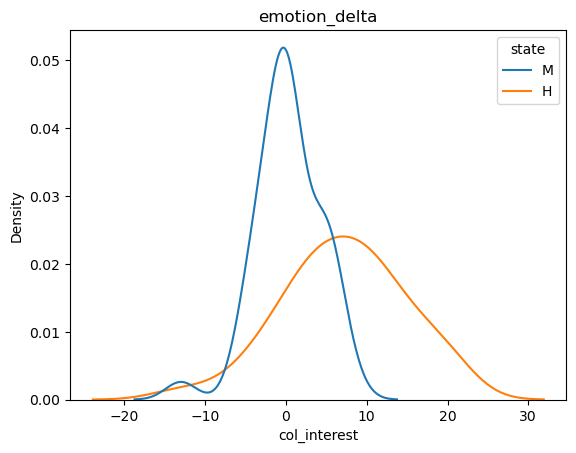

                            OLS Regression Results                            
Dep. Variable:           col_interest   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     9.026
Date:                Thu, 15 Jun 2023   Prob (F-statistic):           3.48e-05
Time:                        10:16:21   Log-Likelihood:                -255.97
No. Observations:                  80   AIC:                             519.9
Df Residuals:                      76   BIC:                             529.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          13.5000      4.909     

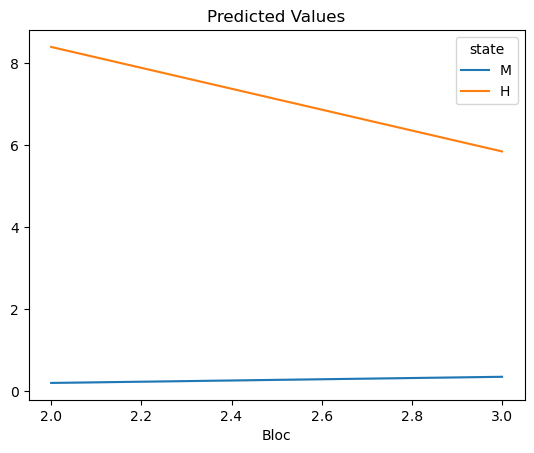

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     H      M    -6.85   0.0 -9.5561 -4.1439   True
---------------------------------------------------
FDR corrected p-values:  [2.95210492e-06]


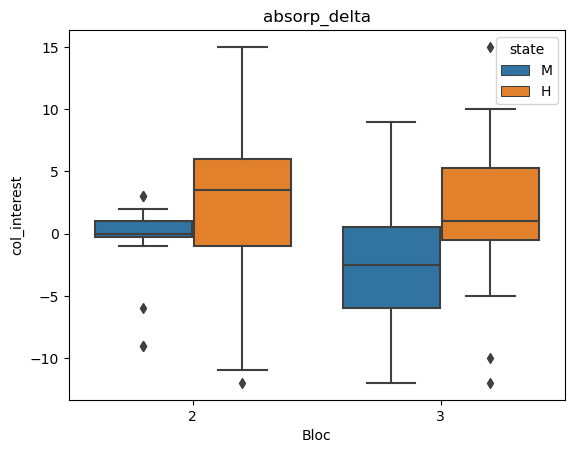

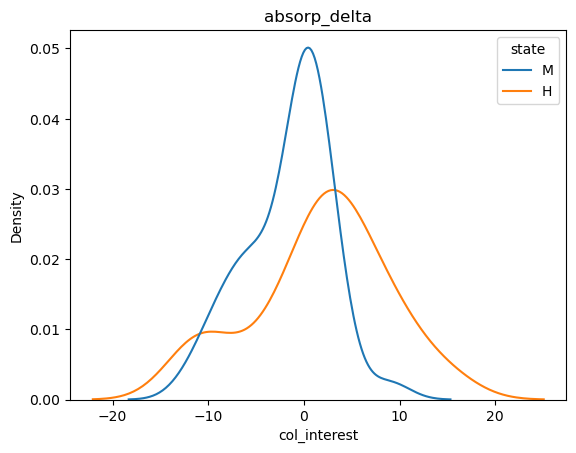

                            OLS Regression Results                            
Dep. Variable:           col_interest   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     2.547
Date:                Thu, 15 Jun 2023   Prob (F-statistic):             0.0622
Time:                        10:16:22   Log-Likelihood:                -253.30
No. Observations:                  80   AIC:                             514.6
Df Residuals:                      76   BIC:                             524.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.2500      4.747     

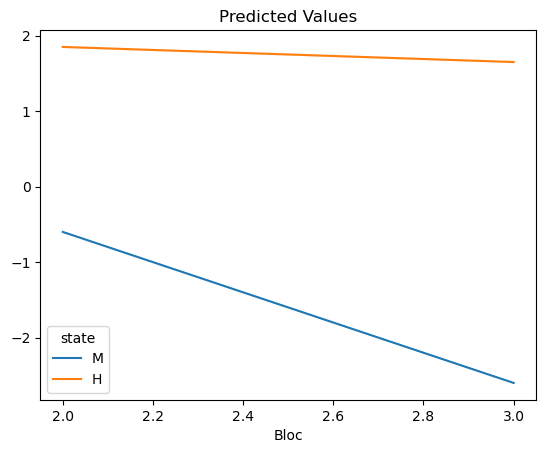

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     H      M    -3.35 0.0125 -5.957 -0.743   True
--------------------------------------------------
FDR corrected p-values:  [0.01245808]


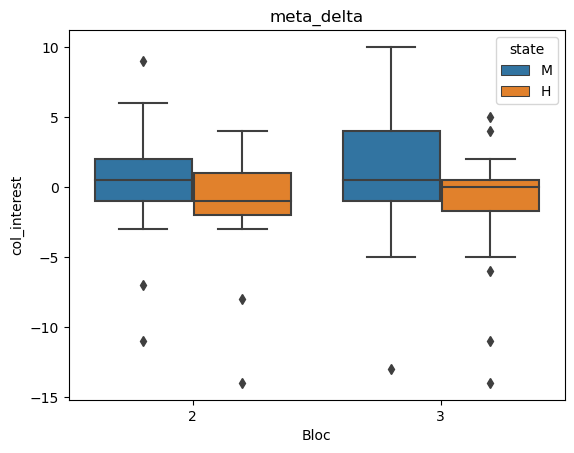

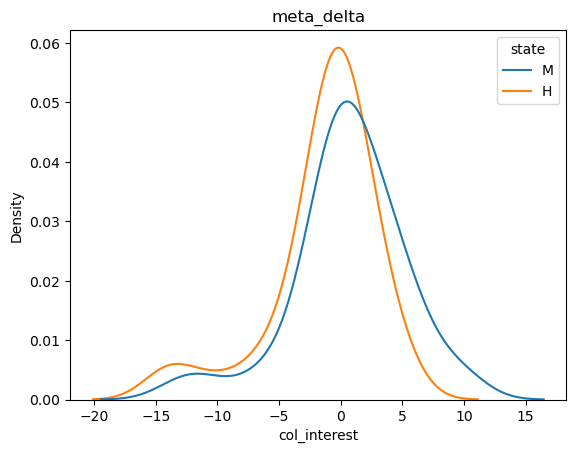

                            OLS Regression Results                            
Dep. Variable:           col_interest   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.342
Date:                Thu, 15 Jun 2023   Prob (F-statistic):              0.267
Time:                        10:16:22   Log-Likelihood:                -230.84
No. Observations:                  80   AIC:                             469.7
Df Residuals:                      76   BIC:                             479.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.8500      3.585     

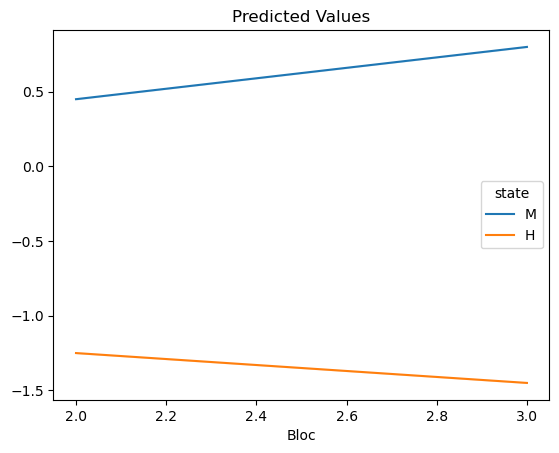

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     H      M    1.975 0.0478 0.0199 3.9301   True
--------------------------------------------------
FDR corrected p-values:  [0.04776824]


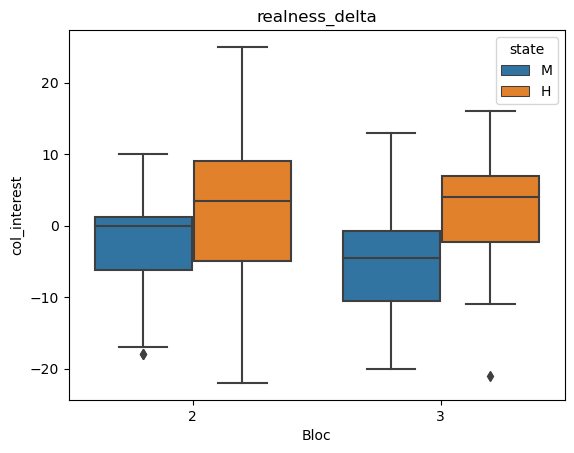

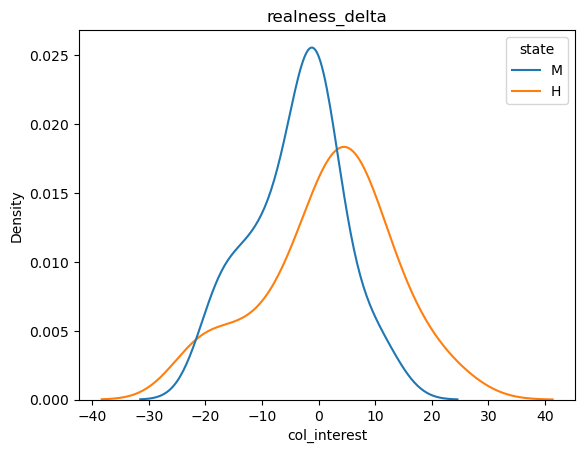

                            OLS Regression Results                            
Dep. Variable:           col_interest   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     2.404
Date:                Thu, 15 Jun 2023   Prob (F-statistic):             0.0740
Time:                        10:16:23   Log-Likelihood:                -295.12
No. Observations:                  80   AIC:                             598.2
Df Residuals:                      76   BIC:                             607.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.8000      8.007     

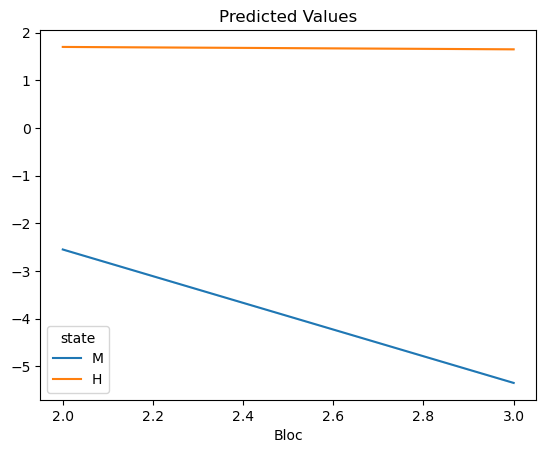

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     H      M   -5.625 0.0126 -10.0119 -1.2381   True
-----------------------------------------------------
FDR corrected p-values:  [0.01264066]


In [26]:
# Iterate through the output list and print results for each variable
from IPython.display import display

var_to_analys = ["difficulty_delta", "emotion_delta", "absorp_delta", "meta_delta", "realness_delta"] 

# Apply analysis_al function to each variable
output = [analysis_al_python(var, data_delta) for var in var_to_analys]


In [27]:
subset_A = data_delta[data_delta["Version"]=='A'] #participants with goup A 
subset_B = data_delta[data_delta["Version"]=='B'] #participants with goup A 

Bloc2 = data_delta[data_delta["Bloc"]==2] 
Bloc3 = data_delta[data_delta["Bloc"]==3]

subset_A_Bloc2 = subset_A[subset_A["Bloc"]==2]
subset_B_Bloc2 = subset_B[subset_B["Bloc"]==2]

subset_A_Bloc3 = subset_A[subset_A["Bloc"]==3]
subset_B_Bloc3 = subset_B[subset_B["Bloc"]==3]




mean_difficulty_delta = pd.DataFrame({
    'Subset': ['Subset A', 'Subset B', 'Bloc 2', 'Bloc 3', 'Subset A Bloc 2', 'Subset B Bloc 2', 'Subset A Bloc 3', 'Subset B Bloc 3'],
    'Mean Difficulty Delta': [
        subset_A['difficulty_delta'].mean(),
        subset_B['difficulty_delta'].mean(),
        Bloc2['difficulty_delta'].mean(),
        Bloc3['difficulty_delta'].mean(),
        subset_A_Bloc2['difficulty_delta'].mean(),
        subset_B_Bloc2['difficulty_delta'].mean(),
        subset_A_Bloc3['difficulty_delta'].mean(),
        subset_B_Bloc3['difficulty_delta'].mean()
    ]
})

print(mean_difficulty_delta)


            Subset  Mean Difficulty Delta
0         Subset A                   1.10
1         Subset B                   0.35
2           Bloc 2                   1.20
3           Bloc 3                   0.25
4  Subset A Bloc 2                   1.95
5  Subset B Bloc 2                   0.45
6  Subset A Bloc 3                   0.25
7  Subset B Bloc 3                   0.25


### Independent samples t-test (testing with difficulty)


In [28]:
import scipy.stats as stats

# performing a t-test to compare the mean differences between subset A and subset B
t_statistic, p_value = stats.ttest_ind(subset_A['difficulty_delta'], subset_B['difficulty_delta'])
print("t-statistic: ", t_statistic)
print("p-value: ", p_value)


# performing a t-test to compare the mean differences between Bloc 2 subset A and Bloc 2 subset B
t_statistic, p_value = stats.ttest_ind(subset_A_Bloc2['difficulty_delta'], subset_B_Bloc2['difficulty_delta'])
print("t-statistic: ", t_statistic)
print("p-value: ", p_value)

# performing a t-test to compare the mean differences between Bloc 3 subset A and Bloc 3 subset B
t_statistic, p_value = stats.ttest_ind(subset_A_Bloc3['difficulty_delta'], subset_B_Bloc3['difficulty_delta'])
print("t-statistic: ", t_statistic)
print("p-value: ", p_value)


t-statistic:  0.9327012357247281
p-value:  0.3538524442141706
t-statistic:  1.3431969686702177
p-value:  0.18717572333559673
t-statistic:  0.0
p-value:  1.0


### Paired t-test (testing with difficulty)

In [29]:
# performing a paired t-test to compare the mean differences between Bloc 2 and Bloc 3
t_statistic, p_value = stats.ttest_rel(Bloc2['difficulty_delta'], Bloc3['difficulty_delta'])
print("t-statistic: ", t_statistic)
print("p-value: ", p_value)

# performing a paired t-test to compare the mean differences between Bloc 2 subset A and Bloc 3 subset B (Meditation)
t_statistic, p_value = stats.ttest_rel(subset_A_Bloc2['difficulty_delta'], subset_B_Bloc3['difficulty_delta'])
print("t-statistic: ", t_statistic)
print("p-value: ", p_value)

# performing a paired t-test to compare the mean differences between Bloc 3 subset A and Bloc 2 subset B (Hypnose)
t_statistic, p_value = stats.ttest_rel(subset_A_Bloc3['difficulty_delta'], subset_B_Bloc2['difficulty_delta'])
print("t-statistic: ", t_statistic)
print("p-value: ", p_value)


t-statistic:  1.1877974624930803
p-value:  0.24209698499795473
t-statistic:  1.27251182556806
p-value:  0.21854404005791794
t-statistic:  -0.22615041624361465
p-value:  0.8234994802702167
